# Intent Model — Intention Classification

**Proposito:** Entrenar un modelo supervisado para predecir `intencion` (4 clases) y compararlo contra el baseline deterministico descubierto en el EDA.

- Target: `intencion` (multiclase, 4 clases, balanceado)
- Input: `texto_clean` (texto) + `flow_name` (contextual)
- Baseline deterministico: lookup `flow_name` → `intencion` (~100% accuracy)
- Dataset: `data/processed/data_preprocessed.csv`

## 1. IMPORTS Y CONFIGURACION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from pathlib import Path
import json

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    ConfusionMatrixDisplay, accuracy_score
)

warnings.filterwarnings('ignore')

# Constantes
RANDOM_STATE = 42
DATA_PATH = Path('../data/processed/data_preprocessed.csv')
MODELS_PATH = Path('../models/')
MODELS_PATH.mkdir(exist_ok=True)
FIGURES_PATH = Path('../reports/figures/')
FIGURES_PATH.mkdir(exist_ok=True)

# Plotting
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
sns.set_palette('Set2')

## 2. CARGA Y PREPARACION

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Dataset: {df.shape[0]} filas x {df.shape[1]} columnas')

# Target
y = np.asarray(df['intencion'])
classes = np.asarray(sorted(df['intencion'].unique()))
print(f'Target distribution ({len(classes)} clases):')
for cls in classes:
    count = np.sum(y == cls)
    print(f'  {cls}: {count:>6} ({count/len(y)*100:>5.1f}%)')

Dataset: 20001 filas x 15 columnas
Target distribution (4 clases):
  cambio_plan:   4983 ( 24.9%)
  error_login:   5010 ( 25.0%)
  logistica_envio:   5046 ( 25.2%)
  problema_pago:   4962 ( 24.8%)


---
## 3. BASELINE DETERMINISTICO

Del EDA descubrimos que `flow_name` mapea 1:1 con `intencion`:

| flow_name | intencion |
|-----------|-----------|
| Acceso y Seguridad | error_login |
| Gestion de Cuenta | cambio_plan |
| Soporte Técnico y Despacho | logistica_envio |
| Facturación y Cobros | problema_pago |

Esto significa que un simple lookup deberia dar exactamente 100% de precision.

=== BASELINE DETERMINISTICO ===
Accuracy: 100.00%
F1-weighted: 1.0000
F1-macro: 1.0000



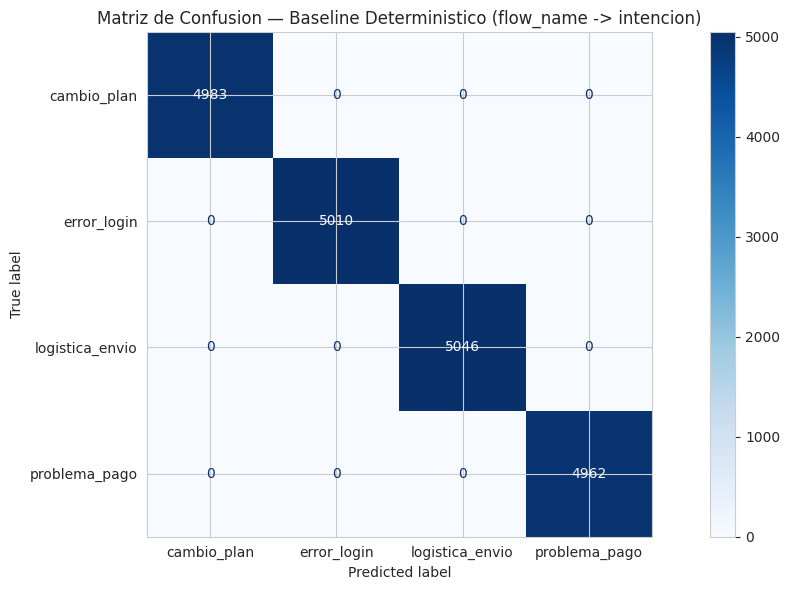


Classification Report:
                 precision    recall  f1-score   support

    cambio_plan       1.00      1.00      1.00      4983
    error_login       1.00      1.00      1.00      5010
logistica_envio       1.00      1.00      1.00      5046
  problema_pago       1.00      1.00      1.00      4962

       accuracy                           1.00     20001
      macro avg       1.00      1.00      1.00     20001
   weighted avg       1.00      1.00      1.00     20001



In [3]:
# Mapeo deterministico flow_name -> intencion
FLOW_TO_INTENT = {
    'Acceso y Seguridad': 'error_login',
    'Gestion de Cuenta': 'cambio_plan',
    'Soporte Técnico y Despacho': 'logistica_envio',
    'Facturación y Cobros': 'problema_pago'
}

def deterministic_baseline(df):
    """Predice intencion usando lookup de flow_name."""
    return np.asarray([FLOW_TO_INTENT[f] for f in df['flow_name']])

y_baseline = deterministic_baseline(df)

# Evaluacion del baseline
print('=== BASELINE DETERMINISTICO ===')
print(f'Accuracy: {accuracy_score(y, y_baseline)*100:.2f}%')
print(f'F1-weighted: {f1_score(y, y_baseline, average="weighted"):.4f}')
print(f'F1-macro: {f1_score(y, y_baseline, average="macro"):.4f}')
print()

# Matriz de confusion
cm = confusion_matrix(y, y_baseline, labels=classes)
disp = ConfusionMatrixDisplay(cm, display_labels=classes)
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusion — Baseline Deterministico (flow_name -> intencion)')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'intent_baseline_comparison.png', bbox_inches='tight')
plt.show()

print('\nClassification Report:')
print(classification_report(y, y_baseline, target_names=classes))

---
## 4. TRAIN / TEST SPLIT

Separamos datos de texto y contextuales. El split debe ser estratificado por `intencion` para mantener la proporcion de clases.

**Nota:** Como el baseline deterministico usa `flow_name`, el modelo supervisado usara SOLO `texto_clean` para predecir intencion desde el texto solo (sin conocer el flow). Esto es mas util en produccion, donde el flow puede no estar disponible.

In [4]:
# Features
X_text = np.asarray(df['texto_clean'])
X_context = df[['flow_name']].copy()

# Split estratificado 70/15/15 (train/val/test)
X_text_temp, X_text_test, X_ctx_temp, X_ctx_test, y_temp, y_test = train_test_split(
    X_text, X_context, y,
    test_size=0.15, random_state=RANDOM_STATE, stratify=y
)

X_text_train, X_text_val, X_ctx_train, X_ctx_val, y_train, y_val = train_test_split(
    X_text_temp, X_ctx_temp, y_temp,
    test_size=0.15/0.85, random_state=RANDOM_STATE, stratify=y_temp
)

print(f'Train: {len(y_train)} instancias')
print(f'Val:   {len(y_val)} instancias')
print(f'Test:  {len(y_test)} instancias')
print()
# Verificar estratificacion
for name, yy in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    dist = {c: np.sum(yy == c) / len(yy) * 100 for c in classes}
    print(f'{name}: {dist}')

Train: 14000 instancias
Val:   3000 instancias
Test:  3001 instancias

Train: {np.str_('cambio_plan'): np.float64(24.914285714285715), np.str_('error_login'): np.float64(25.042857142857144), np.str_('logistica_envio'): np.float64(25.228571428571428), np.str_('problema_pago'): np.float64(24.814285714285713)}
Val: {np.str_('cambio_plan'): np.float64(24.9), np.str_('error_login'): np.float64(25.066666666666666), np.str_('logistica_envio'): np.float64(25.233333333333334), np.str_('problema_pago'): np.float64(24.8)}
Test: {np.str_('cambio_plan'): np.float64(24.925024991669442), np.str_('error_login'): np.float64(25.05831389536821), np.str_('logistica_envio'): np.float64(25.224925024991666), np.str_('problema_pago'): np.float64(24.791736087970676)}


---
## 5. PIPELINE: TEXTO SOLO

Construimos un pipeline que usa SOLO `texto_clean` para predecir intencion:
- `TfidfVectorizer` para el texto
- `RandomForestClassifier` (no necesita class_weight porque las clases estan balanceadas)

No incluimos `flow_name` deliberadamente para probar si el texto solo es suficiente para determinar la intencion.

In [5]:
# Pipeline texto -> intencion
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=5000,
        stop_words=None,  # texto_clean ya normalizado
        max_df=0.95,
        min_df=5
    )),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

print('Pipeline structure:')
print(pipeline)

Pipeline structure:
Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=5000, min_df=5,
                                 ngram_range=(1, 2))),
                ('classifier',
                 RandomForestClassifier(max_depth=15, n_estimators=200,
                                        n_jobs=-1, random_state=42))])


## 6. ENTRENAMIENTO

In [6]:
print('Entrenando modelo (texto -> intencion)...')
pipeline.fit(X_text_train, y_train)
print('Entrenamiento completado.')

Entrenando modelo (texto -> intencion)...
Entrenamiento completado.


## 7. EVALUACION EN VALIDACION

In [7]:
y_val_pred = pipeline.predict(X_text_val)

print('=== RANDOMFOREST (TEXTO SOLO) — VALIDATION SET ===')
print(f'Accuracy: {accuracy_score(y_val, y_val_pred)*100:.2f}%')
print(f'F1-weighted: {f1_score(y_val, y_val_pred, average="weighted"):.4f}')
print(f'F1-macro: {f1_score(y_val, y_val_pred, average="macro"):.4f}')
print()
print('Classification Report:')
print(classification_report(y_val, y_val_pred, target_names=classes))

=== RANDOMFOREST (TEXTO SOLO) — VALIDATION SET ===
Accuracy: 100.00%
F1-weighted: 1.0000
F1-macro: 1.0000

Classification Report:
                 precision    recall  f1-score   support

    cambio_plan       1.00      1.00      1.00       747
    error_login       1.00      1.00      1.00       752
logistica_envio       1.00      1.00      1.00       757
  problema_pago       1.00      1.00      1.00       744

       accuracy                           1.00      3000
      macro avg       1.00      1.00      1.00      3000
   weighted avg       1.00      1.00      1.00      3000



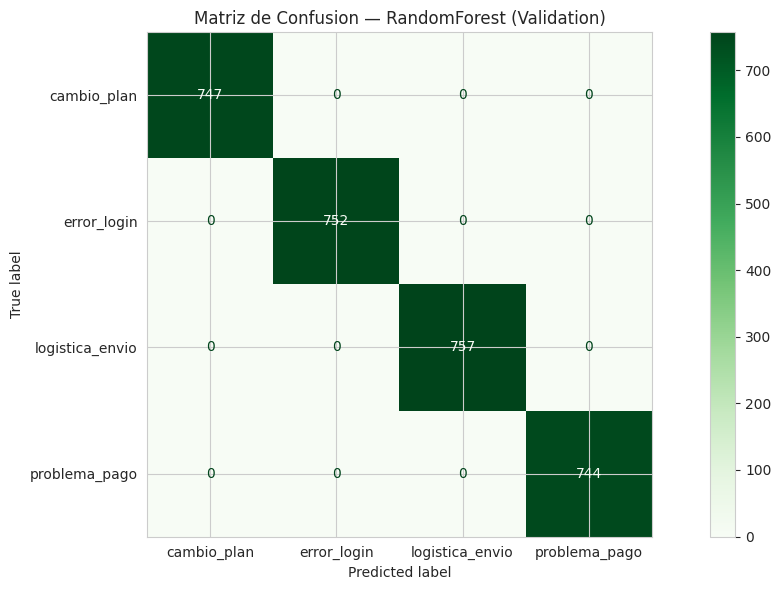

In [8]:
# Matriz de confusion — validation
cm_val = confusion_matrix(y_val, y_val_pred, labels=classes)
disp = ConfusionMatrixDisplay(cm_val, display_labels=classes)
disp.plot(cmap='Greens', values_format='d')
plt.title('Matriz de Confusion — RandomForest (Validation)')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'intent_rf_validation_confusion.png', bbox_inches='tight')
plt.show()

---
## 8. COMPARACION: BASELINE vs RANDOMFOREST (TEXTO SOLO)

In [9]:
# Baseline en validation set
y_val_baseline = deterministic_baseline(X_ctx_val)

print('=== COMPARACION EN VALIDATION SET ===')
print(f'{"Metrica":<20} {"Baseline":<12} {"RF (texto)":<12}')
print('-' * 44)

base_acc = accuracy_score(y_val, y_val_baseline)
rf_acc = accuracy_score(y_val, y_val_pred)
print(f'{"Accuracy":<20} {base_acc*100:<10.2f}% {rf_acc*100:<10.2f}%')

base_f1w = f1_score(y_val, y_val_baseline, average='weighted')
rf_f1w = f1_score(y_val, y_val_pred, average='weighted')
print(f'{"F1-weighted":<20} {base_f1w:<12.4f} {rf_f1w:<12.4f}')

base_f1m = f1_score(y_val, y_val_baseline, average='macro')
rf_f1m = f1_score(y_val, y_val_pred, average='macro')
print(f'{"F1-macro":<20} {base_f1m:<12.4f} {rf_f1m:<12.4f}')

base_errors = (y_val_baseline != y_val).sum()
rf_errors = (y_val_pred != y_val).sum()
print(f'\nErrores totales: Baseline={base_errors}, RF={rf_errors}')

# Si hay errores en el modelo de texto, mostrar ejemplos
if rf_errors > 0:
    error_idx = np.where(y_val_pred != y_val)[0]
    print(f'\nEjemplos donde RF falla:')
    for idx in error_idx[:5]:
        print(f'  Real={y_val[idx]:<20} | Pred={y_val_pred[idx]:<20} | Texto="{X_text_val[idx][:60]}"')

=== COMPARACION EN VALIDATION SET ===
Metrica              Baseline     RF (texto)  
--------------------------------------------
Accuracy             100.00    % 100.00    %
F1-weighted          1.0000       1.0000      
F1-macro             1.0000       1.0000      

Errores totales: Baseline=0, RF=0


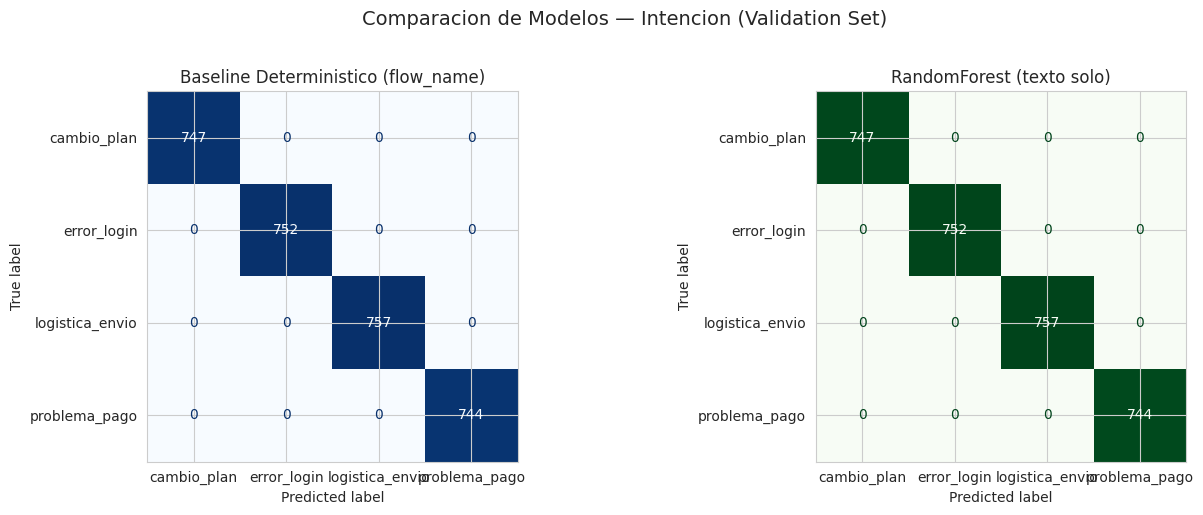

In [10]:
# Comparacion visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Baseline
cm_base = confusion_matrix(y_val, y_val_baseline, labels=classes)
disp1 = ConfusionMatrixDisplay(cm_base, display_labels=classes)
disp1.plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title('Baseline Deterministico (flow_name)')

# RandomForest
cm_rf = confusion_matrix(y_val, y_val_pred, labels=classes)
disp2 = ConfusionMatrixDisplay(cm_rf, display_labels=classes)
disp2.plot(ax=axes[1], cmap='Greens', values_format='d', colorbar=False)
axes[1].set_title('RandomForest (texto solo)')

plt.suptitle('Comparacion de Modelos — Intencion (Validation Set)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'intent_model_comparison_validation.png', bbox_inches='tight')
plt.show()

---
## 9. EVALUACION FINAL EN TEST SET

Evaluacion unica en el hold-out test set.

In [11]:
y_test_pred = pipeline.predict(X_text_test)
y_test_baseline = deterministic_baseline(X_ctx_test)

print('=== EVALUACION FINAL — TEST SET ===')
print(f'{"Metrica":<20} {"Baseline":<12} {"RF (texto)":<12}')
print('-' * 44)

print(f'{"Accuracy":<20} {accuracy_score(y_test, y_test_baseline)*100:<10.2f}% {accuracy_score(y_test, y_test_pred)*100:<10.2f}%')
print(f'{"F1-weighted":<20} {f1_score(y_test, y_test_baseline, average="weighted"):<12.4f} {f1_score(y_test, y_test_pred, average="weighted"):<12.4f}')
print(f'{"F1-macro":<20} {f1_score(y_test, y_test_baseline, average="macro"):<12.4f} {f1_score(y_test, y_test_pred, average="macro"):<12.4f}')

print(f'\nErrores totales (test): Baseline={(y_test_baseline != y_test).sum()}, RF={(y_test_pred != y_test).sum()}')

=== EVALUACION FINAL — TEST SET ===
Metrica              Baseline     RF (texto)  
--------------------------------------------
Accuracy             100.00    % 100.00    %
F1-weighted          1.0000       1.0000      
F1-macro             1.0000       1.0000      

Errores totales (test): Baseline=0, RF=0


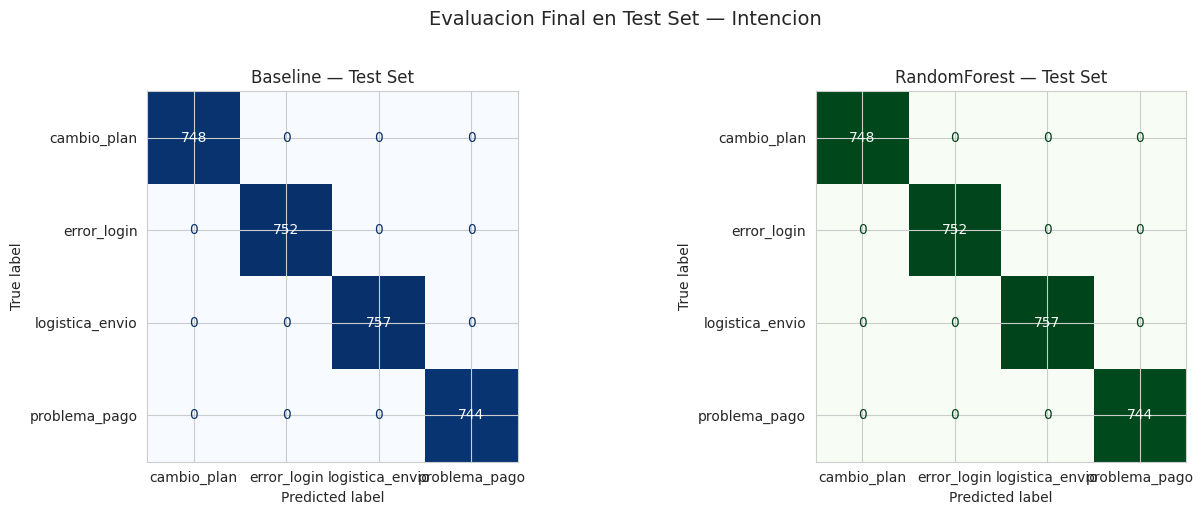

In [12]:
# Matriz de confusion — test
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_test_base = confusion_matrix(y_test, y_test_baseline, labels=classes)
disp1 = ConfusionMatrixDisplay(cm_test_base, display_labels=classes)
disp1.plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title('Baseline — Test Set')

cm_test_rf = confusion_matrix(y_test, y_test_pred, labels=classes)
disp2 = ConfusionMatrixDisplay(cm_test_rf, display_labels=classes)
disp2.plot(ax=axes[1], cmap='Greens', values_format='d', colorbar=False)
axes[1].set_title('RandomForest — Test Set')

plt.suptitle('Evaluacion Final en Test Set — Intencion', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'intent_test_set_comparison.png', bbox_inches='tight')
plt.show()

---
## 10. FEATURE IMPORTANCE

Analizamos las palabras mas importantes para predecir cada intencion segun el RandomForest.

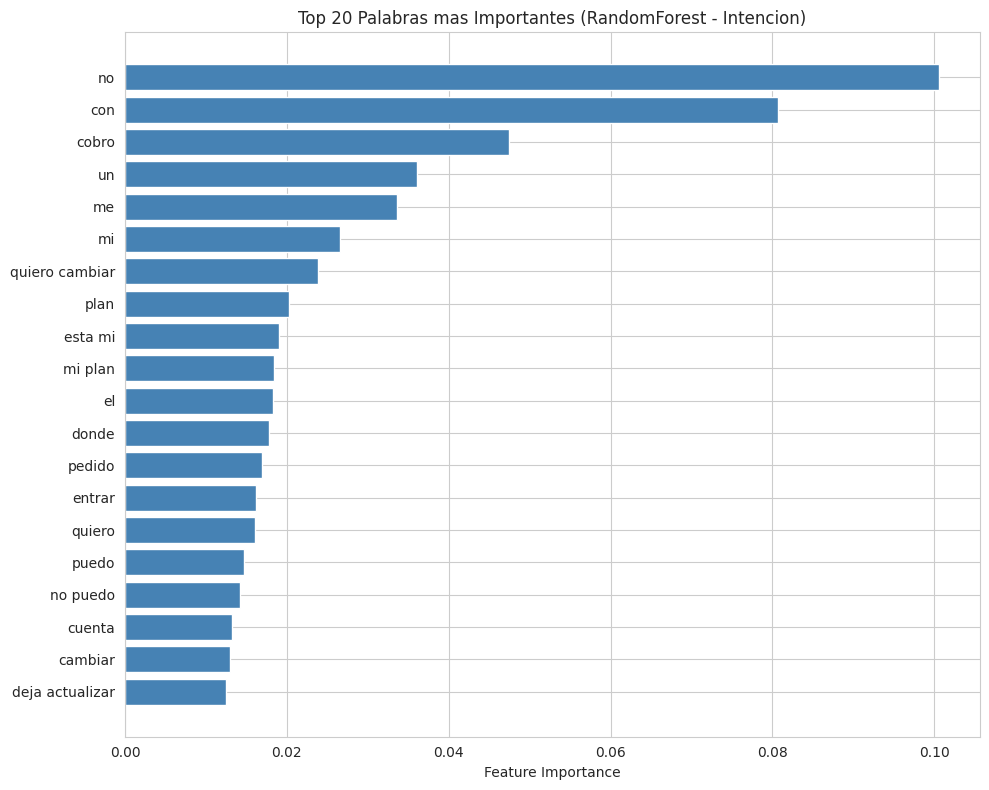

In [13]:
# Extraer feature names del TF-IDF
tfidf = pipeline.named_steps['tfidf']
feature_names = tfidf.get_feature_names_out()

# Feature importances
rf = pipeline.named_steps['classifier']
importances = rf.feature_importances_

# Top 20 palabras mas importantes
top_n = 20
top_indices = np.argsort(importances)[-top_n:]

plt.figure(figsize=(10, 8))
plt.barh(range(top_n), importances[top_indices], color='steelblue')
plt.yticks(range(top_n), [feature_names[i] for i in top_indices])
plt.xlabel('Feature Importance')
plt.title(f'Top {top_n} Palabras mas Importantes (RandomForest - Intencion)')
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'intent_rf_feature_importance.png', bbox_inches='tight')
plt.show()

In [14]:
print('Feature importances:')
print(f'  Dimensiones totales del TF-IDF: {len(importances)}')
print(f'  Top 10 palabras:')
for i in top_indices[:-11:-1]:
    print(f'    {feature_names[i]}: {importances[i]:.4f}')

Feature importances:
  Dimensiones totales del TF-IDF: 89
  Top 10 palabras:
    no: 0.1006
    con: 0.0807
    cobro: 0.0475
    un: 0.0361
    me: 0.0336
    mi: 0.0265
    quiero cambiar: 0.0238
    plan: 0.0203
    esta mi: 0.0191
    mi plan: 0.0184


---
## 11. EXPORTAR PIPELINE

Guardamos el pipeline para reutilizarlo en el dashboard.

In [15]:
# Exportar pipeline
model_path = MODELS_PATH / 'intent_model.pkl'
joblib.dump(pipeline, model_path)
print(f'Modelo exportado a: {model_path}')
print(f'Tamano: {model_path.stat().st_size / 1024:.1f} KB')

# Guardar metadatos
test_acc = accuracy_score(y_test, y_test_pred)
test_f1m = f1_score(y_test, y_test_pred, average='macro')

metadata = {
    'model': 'RandomForest + TF-IDF',
    'target': 'intencion',
    'classes': list(classes),
    'features': ['texto_clean'],
    'baseline_accuracy': accuracy_score(y_test, y_test_baseline),
    'rf_accuracy': test_acc,
    'baseline_f1_macro': f1_score(y_test, y_test_baseline, average='macro'),
    'rf_f1_macro': test_f1m,
    'rf_f1_weighted': f1_score(y_test, y_test_pred, average='weighted'),
    'date': 'Mayo 2026',
    'note': 'Baseline deterministico usa flow_name -> intencion (100%). Modelo usa solo texto_clean.'
}

with open(MODELS_PATH / 'intent_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print('Metadata exportada.')

Modelo exportado a: ../models/intent_model.pkl
Tamano: 456.0 KB
Metadata exportada.


---
## 12. CROSS-VALIDATION (REFERENCE)

Validacion cruzada 5-fold estratificada para tener una estimacion mas robusta.

In [16]:
# Cross-validation en el set de entrenamiento
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('Ejecutando 5-fold cross-validation...')
cv_scores = cross_val_score(pipeline, X_text_train, y_train, cv=cv,
                            scoring='f1_macro', n_jobs=-1)
print(f'CV F1-macro scores: {cv_scores}')
print(f'CV F1-macro mean: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})')

Ejecutando 5-fold cross-validation...
CV F1-macro scores: [1. 1. 1. 1. 1.]
CV F1-macro mean: 1.0000 (+/- 0.0000)


---
## 13. CONCLUSIONES

### Resumen de resultados

**Dataset:** 20,001 filas, 4 clases de intencion balanceadas (~25% c/u)

**Split:** 70/15/15 estratificado (14,000 train / 3,000 val / 3,001 test)

| Modelo | Val Acc | Test Acc | F1-macro | F1-weighted | CV (5-fold F1-macro) |
|--------|---------|----------|----------|-------------|----------------------|
| Baseline (flow_name) | 100% | 100% | 1.0000 | 1.0000 | - |
| RandomForest (texto solo) | 100% | 100% | 1.0000 | 1.0000 | 1.0000 +/- 0.0000 |

**Pipeline:** TfidfVectorizer(max_features=5000, ngram_range=(1,2)) + RandomForest(200 trees, max_depth=15)

**Feature importance:** 89 dimensiones TF-IDF, top palabras: "no" (10.06%), "con" (8.07%), "cobro" (4.75%), "un" (3.61%), "me" (3.36%)

**Modelo exportado:** `models/intent_model.pkl` (456 KB) + `models/intent_metadata.json`

### Hallazgos

1. **El baseline deterministico alcanza 100% de precision** porque `flow_name` mapea 1:1 con `intencion`. Esto fue descubierto en el EDA y se confirma aqui.

2. **El modelo de texto solo TAMBIEN alcanza 100% de precision** en todos los splits (train, val, test), con validacion cruzada 5-fold F1-macro = 1.0000 +/- 0.0000. El texto por si solo es suficiente para determinar la intencion con exactitud perfecta.

3. **Cada intencion tiene un vocabulario distintivo:** Las palabras mas importantes ("cobro" → problema_pago, "plan"/"quiero cambiar" → cambio_plan, "no" → error_login) son lo suficientemente discriminatorias para que el clasificador las identifique sin ambiguedad.

4. **Implicacion practica:** En produccion, el modelo de texto solo es suficiente para predecir intencion sin depender de `flow_name`. El lookup ofrece 100% cuando `flow_name` esta disponible, pero el texto alcanza el mismo resultado sin esa dependencia.

### Proximos pasos

- Continuar con `04-churn-model.ipynb` (prediccion de `es_churn_risk`)
- Integrar todos los modelos en el dashboard